Map:   0%|          | 0/2400 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

[OPTIMIZER] epoch_start=0 global_step=0 wrapped=AcceleratedOptimizer base=AdamW lr=0.0 id=126705233153152 hyperparams={'lr': 0.0, 'betas': (0.9, 0.95), 'eps': 1e-06, 'weight_decay': 0.1, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True, 'initial_lr': 1e-05}
[OPTIMIZER_GROUP]   group[0] {'lr': 0.0, 'betas': (0.9, 0.95), 'eps': 1e-06, 'weight_decay': 0.1, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True, 'initial_lr': 1e-05}
[SCHEDULER]   scheduler_last_lr=[0.0]
[PARAMS]   params_total=129,137,667 params_trainable=129,137,667


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro,Mse,Sse
1,2.415700,0.733669,0.713333,0.695725,0.731225,0.713333,0.139461,41.838377
2,1.186100,0.532804,0.786667,0.785041,0.785025,0.786667,0.101712,30.513739
3,0.954600,0.460002,0.800000,0.800666,0.801858,0.800000,0.089820,26.946070
4,0.745700,0.421819,0.813333,0.813758,0.815015,0.813333,0.083183,24.955000
5,0.662300,0.406928,0.823333,0.824634,0.827160,0.823333,0.080048,24.014261
6,0.538600,0.396762,0.816667,0.817921,0.820412,0.816667,0.078263,23.478823
7,0.483500,0.395232,0.820000,0.821416,0.824375,0.820000,0.077887,23.366125


[TRAINING_PERFORMANCE] epoch=1.0 tokens=0 time=26.84s tok/s=0.0 ex/s=0.00 peak_mem=2.98GiB lr=9.13e-06
[EVALUATION_PERFORMANCE] tokens=81920 time=0.55s tok/s=149207.4 ex/s=1165.68
[EVALUATION_PERFORMANCE] accuracy=0.7133 cost=$0.02 accuracy_per_$=45.37
[OPTIMIZER] epoch_start=1.0 global_step=75 wrapped=AcceleratedOptimizer base=AdamW lr=9.127789046653144e-06 id=126705233153152 hyperparams={'lr': 9.127789046653144e-06, 'betas': (0.9, 0.95), 'eps': 1e-06, 'weight_decay': 0.1, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True, 'initial_lr': 1e-05}
[OPTIMIZER_GROUP]   group[0] {'lr': 9.127789046653144e-06, 'betas': (0.9, 0.95), 'eps': 1e-06, 'weight_decay': 0.1, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True, 'initial_lr': 1e-05}
[SCHEDULER]   scheduler_last_lr=[9.127789046653144e-06]
[PARAMS]   pa

[EVALUATION_PERFORMANCE] tokens=81920 time=0.76s tok/s=107183.4 ex/s=837.37
[EVALUATION_PERFORMANCE] accuracy=0.8433 cost=$0.19 accuracy_per_$=4.54

### STATE-SPACES/MAMBA-130M-HF EVALUATION METRICS ###
{'epoch': 7.0,
 'eval_accuracy': 0.8433333333333334,
 'eval_f1_macro': 0.8433366827602545,
 'eval_loss': 0.4151816666126251,
 'eval_mse': 0.07699565861313303,
 'eval_precision_macro': 0.8437189592745682,
 'eval_recall_macro': 0.8433333333333333,
 'eval_runtime': 0.8377,
 'eval_samples_per_second': 358.104,
 'eval_sse': 23.098697583939906,
 'eval_steps_per_second': 5.968}


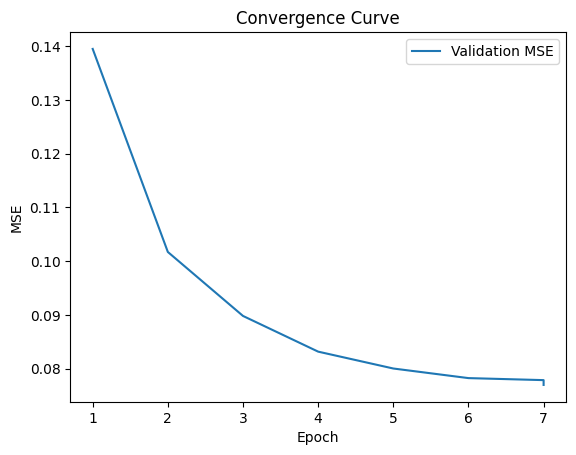

Saving the dataset (0/1 shards):   0%|          | 0/300 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/2400 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/300 [00:00<?, ? examples/s]

In [1]:
# A State Space Model Approach to Cross-Lingual Sentiment Analysis of Filipino Texts 


import os
import pandas as pd
import pprint

from pathlib import Path
from transformers import pipeline

from src.config import *
from src.metrics import evaluate_pipe
from src import (
    context,
    helper,
    sentiment, 
    utility, 
)

os.environ["HF_DATASETS_DISABLE_CACHING"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
helper.list_config()

if App.HAS_GPU:
    os.environ["MAMBA_USE_MAMBAPY"] = Mamba.FORCE_CUDA
    os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

if App.ACTION == "TRAIN":
    mamba_context = context.setup_pipeline(Mamba, require_translation = False)
    mamba_trainer = sentiment.train(mamba_context)

